<a href="https://colab.research.google.com/github/devendrasinghr284/NLP_Customer_Dispute_Prediction/blob/main/Env_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_core openai

In [8]:
"""import openai
from google.colab import userdata

client = openai.OpenAI(
    # This is the default and can be omitted
    api_key=userdata.get('OPENAI_API_KEY'),
)

response = client.responses.create(
    model="gpt-4o",
    instructions="You are a very helpful assistant.",
    input="What is the capital of France?",
)

print(response.output_text)"""

RateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

In [10]:
from google import genai
from google.colab import userdata

# Get API key from Colab Secrets
api_key = userdata.get("GEMINI_API_KEY")

# Create client
client = genai.Client(api_key=api_key)

# Generate response
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="What is the capital of France?",
    config={
        "system_instruction": "You are a very helpful assistant."
    }
)

print(response.text)

The capital of France is **Paris**.


In [11]:
from typing_extensions import TypedDict

class SimpleState(TypedDict):
  state: str

In [12]:
# simple graph nodes
def node_1(state: SimpleState) -> SimpleState:
  print("Node 1 executed")
  return {"state": state["state"] + " I am"}

def node_2(state: SimpleState) -> SimpleState:
  print("Node 2 executed")
  return {"state": state["state"] + " here"}

def node_3(state: SimpleState) -> SimpleState:
  print("Node 3 executed")
  return {"state": state["state"] + " there"}

In [13]:
import random
from typing import Literal

# Router
def find_me(state: SimpleState) -> Literal["node_2", "node_3"]:
  if random.random() < 0.5:
    return "node_2"
  else:
    return "node_3"

In [14]:
from langgraph.graph import StateGraph, START, END

# initialize a graph
graph_builder = StateGraph(SimpleState)

# add nodes
graph_builder.add_node("node_1", node_1)
graph_builder.add_node("node_2", node_2)
graph_builder.add_node("node_3", node_3)

#add edges
graph_builder.add_edge(START, "node_1")
graph_builder.add_conditional_edges("node_1", find_me)
graph_builder.add_edge("node_2", END)
graph_builder.add_edge("node_3", END)

# Compile the graph
graph = graph_builder.compile()

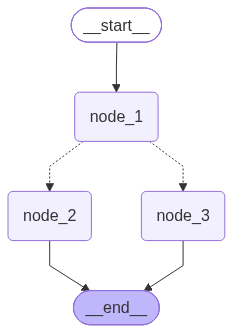

In [15]:
# Draw the graph
from IPython.display import Image, display
png = graph.get_graph().draw_mermaid_png()
display(Image(png))


In [16]:
graph.invoke({"state": "Can you find me?"})

Node 1 executed
Node 2 executed


{'state': 'Can you find me? I am here'}